In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# NeuroAlign-preprocess
from neuroalign_preprocessing.loaders import AnatomicalLoader, DiffusionLoader, QuestionnaireLoader
from neuroalign_preprocessing.preprocessing import FeatureStore

_ = load_dotenv()

In [2]:
# Helper to get paths from env
def get_path(var: str) -> Path | None:
    val = os.getenv(var)
    return Path(val).expanduser() if val else None

# Print current configuration
print("Current Configuration:")
print(f"  SESSIONS_CSV: {get_path('SESSIONS_CSV')}")
print(f"  CAT12_ROOT: {get_path('CAT12_ROOT')}")
print(f"  CAT12_ATLAS_ROOT: {get_path('CAT12_ATLAS_ROOT')}")
print(f"  QSIPARC_PATH: {get_path('QSIPARC_PATH')}")
print(f"  QSIRECON_PATH: {get_path('QSIRECON_PATH')}")
print(f"  ATLAS_NAME: {os.getenv('ATLAS_NAME', '4S456Parcels')}")

Current Configuration:
  SESSIONS_CSV: /home/galkepler/Downloads/linked_sessions.csv
  CAT12_ROOT: /media/storage/yalab-dev/BIDS/derivatives/CAT12.9_2577.new
  CAT12_ATLAS_ROOT: /mnt/62/Processed_Data/derivatives/qsirecon/atlases
  QSIPARC_PATH: /mnt/62/Processed_Data/derivatives/qsiparc
  QSIRECON_PATH: /mnt/62/Processed_Data/derivatives/qsirecon
  ATLAS_NAME: 4S456Parcels


In [10]:
OUTPUT_DIR = Path("/media/storage/neuroalign/data")


In [11]:
# Load the feature store
store = FeatureStore(OUTPUT_DIR)

# Check if store exists
if store.exists():
    print("FeatureStore found!")
    summary = store.summary()
    print(f"\nSummary:")
    print(f"  Sessions: {summary['n_sessions']}")
    print(f"  Subjects: {summary['n_subjects']}")
    print(f"  Atlas: {summary['atlas_name']}")
    print(f"  Has TIV: {summary['has_tiv']}")
    print(f"  Created: {summary['created_at']}")
    
    print(f"\nLong formats available: {len(summary['long_formats'])}")
    for fmt in summary['long_formats']:
        print(f"  - {fmt}")
    
    print(f"\nWide features available: {summary['n_wide_features']}")
else:
    print("FeatureStore not found - run the pipeline first!")

FeatureStore found!

Summary:
  Sessions: 4123
  Subjects: 3231
  Atlas: 4S456Parcels
  Has TIV: True
  Created: 2026-01-31T01:31:04.008524

Long formats available: 61
  - anatomical_gm
  - anatomical_wm
  - diffusion_DSIStudio
  - anatomical_ct
  - diffusion_DIPYDKI
  - diffusion_DIPYMAPMRI
  - diffusion_AMICONODDI
  - diffusion_MRtrix3_act-HSVS
  - diffusion_DSIStudio_tyy
  - diffusion_DSIStudio_txy
  - diffusion_DSIStudio_qa
  - diffusion_DSIStudio_md
  - diffusion_DSIStudio_ad
  - diffusion_DSIStudio_txx
  - diffusion_DSIStudio_rd1
  - diffusion_DSIStudio_iso
  - diffusion_DSIStudio_ha
  - diffusion_DSIStudio_rd2
  - diffusion_DSIStudio_rd
  - diffusion_DSIStudio_tzz
  - diffusion_DSIStudio_fa
  - diffusion_DSIStudio_tyz
  - diffusion_DSIStudio_gfa
  - diffusion_DSIStudio_txz
  - diffusion_DIPYDKI_kfa
  - diffusion_DIPYDKI_axonald
  - diffusion_DIPYDKI_ad
  - diffusion_DIPYDKI_rk
  - diffusion_DIPYDKI_rd
  - diffusion_DIPYDKI_planarity
  - diffusion_DIPYDKI_md
  - diffusion_DIPYDKI

In [32]:
metric = "diffusion_DSIStudio_md"
metric_long = store.load_long(metric)
metadata = store.load_metadata()

# metric_long = pd.read_parquet(OUTPUT_DIR / "long" / "diffusion" / "DSIStudio.parquet")
# store.load_long?

In [33]:

columns_to_fill = ["Age@Scan", "Gender", "Study", "Group"]

# fill missing columns in metric_long from metadata
metric_long = metric_long.merge(
    metadata[["subject_code", "session_id"] + columns_to_fill],
    on=["subject_code", "session_id"],
    how="left",
)

metric_long["subject_code"].nunique()

# metric_long = metric_long[metric_long["param"] == "md"]

3042

In [34]:
# convert long to wide - "subject_code","session_id" + [indices from atlas ("index" column)] + "tiv" + age
# metric_long.pivot_table(index=["subject_code", "session_id", "Age@Scan", "tiv"], columns="index",values="volume_mm3").reset_index().to_csv("~/Downloads/gm_volume_yaniv.csv", index=False)
metric_long[metric_long["param"] == "md"].pivot_table(
    index=["subject_code", "session_id", "Age@Scan", "Gender"],
    columns="index",
    values="robust_mean",
).reset_index().to_csv("/home/galkepler/Downloads/dsi_studio_md_yaniv.csv", index=False)
# metric_long["subject_code"]
# metric_long


In [35]:
df = pd.read_csv("https://docs.google.com/spreadsheets/d/1gzs_8BlTOIpuunz061q-LO5txFMynaH2NE7P0fGg4Rg/export?format=csv&id=1gzs_8BlTOIpuunz061q-LO5txFMynaH2NE7P0fGg4Rg&gid=0")
df["session_id"] = df["ScanID"].astype(str).apply(lambda x: x.replace("_", "").replace("-", ""))
df["subject_code"] = df["SubjectCode"].astype(str).apply(lambda x: x.replace("_", "").replace("-", "").zfill(4))

In [36]:
qcenter = pd.read_csv("/home/galkepler/Downloads/qcenter.csv")
qcenter["subject_code"] = qcenter["Subject Code"].astype(str).apply(lambda x: x.replace("_", "").replace("-", ""))
qcenter = qcenter.dropna(subset="Subject Code")
display(qcenter.shape)

/tmp/ipykernel_574536/1727028984.py:1: DtypeWarning: Columns (0,1,2,3,4,6,8,9,11,14,15,16,17,18,19,23,28,29,30,31,32,33,34,36,37,38,40,41,42,43,52,53,55,56,58,70,71,72,73,74,75,78,79,80,81,82,83,86,87,88,89,90,91,92,93,94,99,102,103,104,109,110,111,112,113,115,116,118,128) have mixed types. Specify dtype option on import or set low_memory=False.
  qcenter = pd.read_csv("/home/galkepler/Downloads/qcenter.csv")


(3425, 131)

In [37]:
available_sessions = set(metric_long["session_id"].values)
def find_session_in_metric_long(row):
    session_id = row["session_id"]
    if session_id in available_sessions:
        return True
    else:
        return False

df["CAT12_exists"] = False
df["CAT12_exists"] = df.apply(find_session_in_metric_long, axis=1)

In [38]:
sessions = pd.read_csv(get_path("SESSIONS_CSV"))
sessions["subject_code"] = sessions["subject_code"].astype(str).apply(lambda x: x.replace("_", "").replace("-", "").zfill(4))

missing_sessions = df.loc[~df["CAT12_exists"].astype(bool), "ScanID"].values
missing_df = sessions.set_index("ScanID").loc[[s for s in missing_sessions if s in sessions["ScanID"].values]]
missing_df[missing_df["dicom_path"].notna()]

,Status,Lab,Name,ID,Cellular No.,Email,Gender,DOB,ScanDate,Age@Scan,...,ScanTag,SubjectCode,HebrewName,No of Scan,PrivacyStatement,UID,session_id,subject_code,dicom_path,match_type
ScanID,,,,,,,,,,,,,,,,,,,,,
20260118_1247,Performed,YA,Nir Kedmi,43401652.0,524588486,Ndk.shows@gmail.com,Male,09/26/1981,01/18/2026,44.312115,...,Post,BJJ_L_253,ניר קדמי,2.0,08/27/2025: Yes,NaN,2.026012e+11,BJJL253,/mnt/62/Raw_Data/20260118_1247,exact
20260113_1239,Performed,YA,Eliyahu Boyarski,38113247.0,052-6139797,Eli@Boyar.ski,Male,05/15/1986,01/13/2026,39.665982,...,Post,BJJ_L_264,אליהו בוירסקי,2.0,10/19/2025: Yes,NaN,2.026011e+11,BJJL264,/mnt/62/Raw_Data/20260113_1239,exact
20250606_1113,Performed,YA,Yarden Kadman,21766886.0,052-8506460,yarden.kadman@gmail.com,Male,9/7/1983,6/6/2025,41.750000,...,Pre,BJJ_C_25,ירדן קדמן,2.0,06/06/2025: Yes,S003318,2.025061e+11,BJJC25,/mnt/62/Raw_Data/20250606_1113,exact
20241126_0908,Performed,YA,Lior Castro,323807214.0,509176555,liorlior1439@gmail.com,Male,9/1/2001,11/26/2024,23.240000,...,Pre,BJJ_L_108,ליאור קסטרו,2.0,11/26/2024: Yes,S002839,2.024113e+11,BJJL108,/mnt/62/Raw_Data/20241126_0908,exact
20241104_1306,Performed,SNBB,Cohen Zedek,215456484.0,NaN,NaN,Female,4/15/2005,11/04/2024,19.550000,...,NaN,0,כהן צדק,3.0,07/24/2024: Yes,S002571,2.024110e+11,0000,/mnt/62/Raw_Data/20241104_1306,exact
20240812_0823,Performed,YA,Yogev Halechmi,201163094.0,052-4391020,yogev.halahmi@gmail.com,Male,03/03/1990,08/12/2024,34.440000,...,Post,BJJ_C_5,יוגב הלחמי,2.0,05/26/2024: Yes,S002427,2.024081e+11,BJJC5,/mnt/62/Raw_Data/20240812_0823,exact
20240625_1745,Performed,YA,Nimrod Weissberg,204663421.0,054-6830223,Nimrod@weissberg.biz,Male,6/2/1992,6/25/2024,32.060000,...,NaN,BJJ_P_10,נימרוד וייסברג,1.0,06/25/2024: Yes,S002490,2.024063e+11,BJJP10,/mnt/62/Raw_Data/20240625_1745,exact
20230824_1816,Performed,YA,Evgeny German,305841793.0,547573086,egerman1983@gmail.com,Male,11/03/1983,08/24/2023,39.810000,...,NaN,1061,יבגני גרמן,1.0,08/24/2023: Yes,S001964,2.023082e+11,1061,/mnt/62/Raw_Data/20230824_1816,exact
20221213_1113,Performed,YA,Shai Hawi,43424613.0,052-6766005,shai82hawi@gmail.com,Male,4/19/1982,12/13/2022,40.650000,...,NaN,580,שי האווי,3.0,01/04/2022: No,S000325,2.022121e+11,0580,/mnt/62/Raw_Data/20221213_1113,exact


In [39]:
metric_bjj = metric_long[metric_long["session_id"].isin(df.loc[df["CAT12_exists"].astype(bool), "session_id"].values)]

In [40]:
qcenter["TimesTrainingPerWeek"].value_counts()

TimesTrainingPerWeek
2                285
3                280
1                164
4                156
5                112
0                107
6                 60
7                 44
10 שעות ויותר      5
9                  5
8                  3
10                 2
14                 1
Name: count, dtype: int64

In [41]:
# Step #1: Cross-sectional comparison between BJJ athletes and non-athletes
max_workouts = 1
workouts_mapper = {
    "10 שעות ויותר": 10,
}
qcenter["workout_freq"] = qcenter["TimesTrainingPerWeek"].replace(workouts_mapper).astype(float)

naive_subjects = qcenter[(qcenter["workout_freq"].notna()) & (qcenter["workout_freq"] < max_workouts)]["subject_code"].unique().tolist()

athlete_query = "(Study == 'BJJ') & (Group in ['Control', 'Professional'])"
learners_query = "(Study == 'BJJ') & (Group == 'Learning')"

athlete_subjects = metric_long.query(athlete_query)["subject_code"].unique().tolist()
learner_subjects = metric_long.query(learners_query)["subject_code"].unique().tolist()

naive_subjects = [s for s in naive_subjects if s not in athlete_subjects]

In [42]:
print(f"Naive subjects: {len(naive_subjects)}")
print(f"Athlete subjects: {len(athlete_subjects)}")
print(f"Learner subjects: {len(learner_subjects)}")

Naive subjects: 107
Athlete subjects: 58
Learner subjects: 150


In [55]:
metric_long["session_id"].nunique()

3958

In [43]:
atlas_name = "4S456Parcels"
parcels_tsv = get_path("CAT12_ATLAS_ROOT") / f"atlas-{atlas_name}" / f"atlas-{atlas_name}_dseg.tsv"
parcels_image_path = get_path("CAT12_ATLAS_ROOT") / f"atlas-{atlas_name}" / f"atlas-{atlas_name}_space-MNI152NLin2009cAsym_res-01_dseg.nii.gz"
parcels = pd.read_csv(parcels_tsv, sep="\t")

In [44]:
# do statistics. First - cross sectional (athletes vs naive)
import statsmodels.formula.api as smf
import warnings
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm

warnings.filterwarnings("ignore")


roi_data_columns = ["subject_code","session_id"]



if "anatomical" in metric and "ct" not in metric:
    roi_data_columns += ["tiv"]
    formula = "volume_mm3 ~ C(condition, Treatment('Naive')) + age_at_scan + C(Gender) + tiv"
else:
    formula = "robust_mean ~ C(condition, Treatment('Naive')) + age_at_scan + C(Gender)"

def tag_cross_sectional(subject_code:str):
    if subject_code in athlete_subjects:
        return "Athlete"
    elif subject_code in naive_subjects:
        return "Naive"
    else:
        return None

coeff_name = "C(condition, Treatment('Naive'))[T.Athlete]"

cs_stats = parcels.copy()

for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0]):
    label = row["label"]
    roi_data = metric_long[metric_long["label"] == label]
    roi_data["condition"] = roi_data["subject_code"].apply(lambda x: tag_cross_sectional(x))
    # propensity scores based on prevelance
    roi_data = roi_data.dropna(subset="condition")
    roi_data = roi_data.sort_values(["subject_code","session_id"]).drop_duplicates(subset=["subject_code"], keep="first")
    sample_weights = 1 - roi_data["condition"].value_counts(normalize=True)
    roi_data["sample_weight"] = roi_data["condition"].replace(sample_weights)
    roi_data["age_at_scan"] = roi_data["Age@Scan"]
    model = smf.wls(formula, data=roi_data, weights = roi_data["sample_weight"]).fit()
    # model = smf.ols("volume_mm3 ~ C(condition, Treatment('Naive')) + age_at_scan + C(Gender)", data=roi_data).fit()
    cs_stats.loc[i,"coeff"] = model.params[coeff_name]
    cs_stats.loc[i,"t"] = model.tvalues[coeff_name]
    cs_stats.loc[i,"p"] = model.pvalues[coeff_name]
    # break


notna_rois = cs_stats["p"].notna()
cs_stats.loc[notna_rois, "p_fdr"] = multipletests(cs_stats.loc[notna_rois, "p"], method="fdr_bh")[1]

100%|██████████| 456/456 [00:32<00:00, 14.20it/s]


In [51]:
# Second - longitudinal comparison (learners after - before)
import statsmodels.formula.api as smf
import warnings
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm

warnings.filterwarnings("ignore")


roi_data_columns = ["subject_code","session_id"]



if "anatomical" in metric and "ct" not in metric:
    roi_data_columns += ["tiv"]
    formula = "volume_mm3 ~ C(timepoint, Treatment(0)) + age_at_scan + C(Gender) + tiv"
else:
    formula = "iqr_filtered_mean ~ C(timepoint, Treatment(0)) + age_at_scan + C(Gender)"

def tag_cross_sectional(subject_code:str):
    if subject_code in athlete_subjects:
        return "Athlete"
    elif subject_code in naive_subjects:
        return "Naive"
    elif subject_code in learner_subjects:
        return "Learner"
    else:
        return None

coeff_name = "C(condition, Treatment('Naive'))[T.Athlete]"

long_stats = parcels.copy()

for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0]):
    label = row["label"]
    roi_data = metric_long[metric_long["label"] == label]
    roi_data["condition"] = roi_data["subject_code"].apply(lambda x: tag_cross_sectional(x))
    roi_data = roi_data[roi_data["condition"].str.lower().isin(["learner"])]
    # Keep only participants with more than one session
    participant_session_counts = roi_data["subject_code"].value_counts()
    valid_participants = participant_session_counts[participant_session_counts > 1].index
    roi_data = roi_data[roi_data["subject_code"].isin(valid_participants)]
    # keep only first and last sessions
    roi_data = roi_data.sort_values(["subject_code","session_id"])
    valid_roi_data = []
    for subject_code, group in roi_data.groupby("subject_code"):
        first_session = group.iloc[0]
        last_session = group.iloc[-1]
        valid_roi_data.append(first_session)
        valid_roi_data.append(last_session)
    roi_data = pd.DataFrame(valid_roi_data)
        
    
    # create timepoint variable
    roi_data = roi_data.sort_values(["subject_code","session_id"])
    roi_data["timepoint"] = roi_data.groupby("subject_code").cumcount()
    roi_data["age_at_scan"] = roi_data["Age@Scan"]
    # do mixed effects model
    model = smf.mixedlm(formula, data=roi_data, groups=roi_data["subject_code"]).fit()
    long_stats.loc[i,"coeff"] = model.params["C(timepoint, Treatment(0))[T.1]"]
    long_stats.loc[i,"t"] = model.tvalues["C(timepoint, Treatment(0))[T.1]"]
    long_stats.loc[i,"p"] = model.pvalues["C(timepoint, Treatment(0))[T.1]"]

notna_rois = long_stats["p"].notna()
long_stats.loc[notna_rois, "p_fdr"] = multipletests(long_stats.loc[notna_rois, "p"], method="fdr_bh")[1]
    

100%|██████████| 456/456 [01:19<00:00,  5.71it/s]


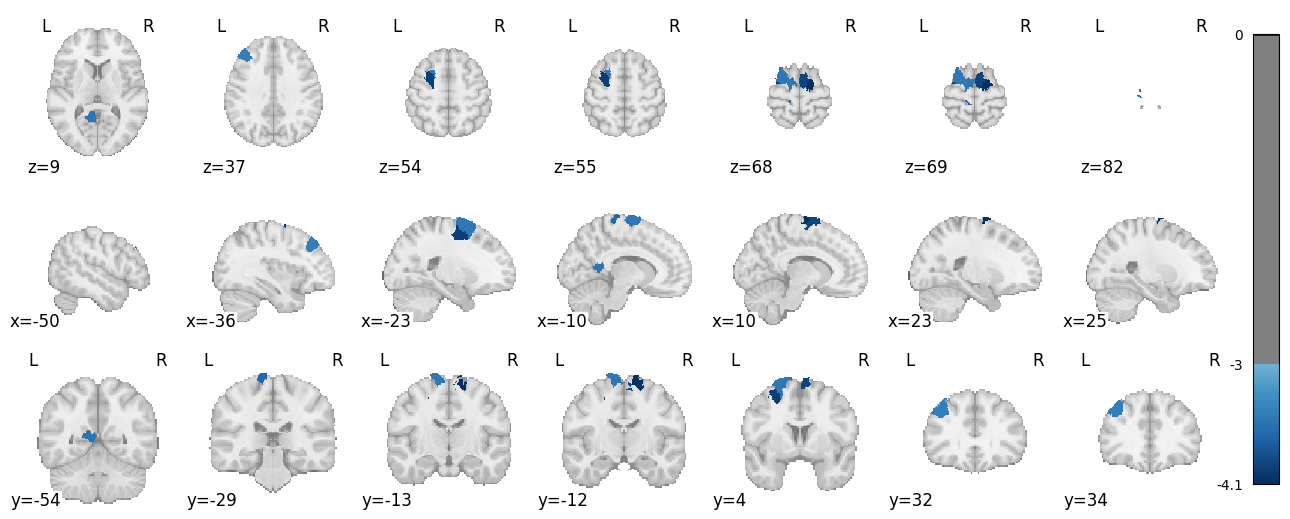

In [53]:
from nilearn.plotting import plot_stat_map,plot_glass_brain, plot_surf_stat_map, view_img_on_surf, plot_surf_contours
import nibabel as nib
import numpy as np
# t visualization
atlas_img = nib.load(parcels_image_path)
# replace atlas data with t-values
atlas_data = atlas_img.get_fdata()
t_map_data = np.zeros(atlas_data.shape)

for i, row in cs_stats.iterrows():
    label = row["index"]
    t_value = row["t"]
    p_value = row["p_fdr"]
    if p_value >= 0.05:
        continue
    t_map_data[atlas_data == label] = t_value
    # break

t_map_img = nib.Nifti1Image(t_map_data, atlas_img.affine, atlas_img.header)
plot_stat_map(
    t_map_img,
    # surf_mesh="fsaverage",
    # hemi="left",
    # title="BJJ Athletes vs Naive - t-values",
    colorbar=True,
    threshold=3.0,
    display_mode="mosaic",
    # cut_coords=list(range(0, 51, 10)),
)